# Unembedding Hypothesis Evaluation

This notebook evaluates the correlation between geometric metrics (Cosine Similarity and Dot Product) in the unembedding space and the empirical improvement ratios observed during our large-scale "subliminal prompting" animal evaluation.

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
cache_path = '../experiments/cache/unembedding_metrics.json'
with open(cache_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Filter out 0 or negative ratios for log analysis
df = df[df['empirical_ratio'] > 0]

# Add log ratio for better trend line fitting
df['log_ratio'] = np.log10(df['empirical_ratio'])

display(df.head())

,animal,number,empirical_ratio,dot_product,cosine_similarity,animal_token_id,number_token_id,log_ratio
0,dogs,082,0.102827,0.032455,0.038938,5679,24996,-0.987891
1,cats,855,1.275361,0.032763,0.035994,8415,22869,0.105633
2,lions,409,4.309193,0.032183,0.037884,40132,12378,0.634396
3,tigers,356,677.538118,0.068901,0.100994,81389,18349,2.830934
4,bears,17,2.284824,0.033202,0.036219,11984,1114,0.358853


## 1. Correlation Analysis
We calculate the correlation between geometric metrics and the empirical log-ratio using numpy.

In [2]:
cosine_pearson = np.corrcoef(df['cosine_similarity'], df['log_ratio'])[0, 1]
dot_pearson = np.corrcoef(df['dot_product'], df['log_ratio'])[0, 1]

print(f"Cosine Similarity vs Log Ratio Correlation (Pearson): {cosine_pearson:.4f}")
print(f"Dot Product vs Log Ratio Correlation (Pearson):       {dot_pearson:.4f}")

Cosine Similarity vs Log Ratio Correlation (Pearson): -0.1164
Dot Product vs Log Ratio Correlation (Pearson):       -0.1111


## 2. Scatter Plots with Trend Lines

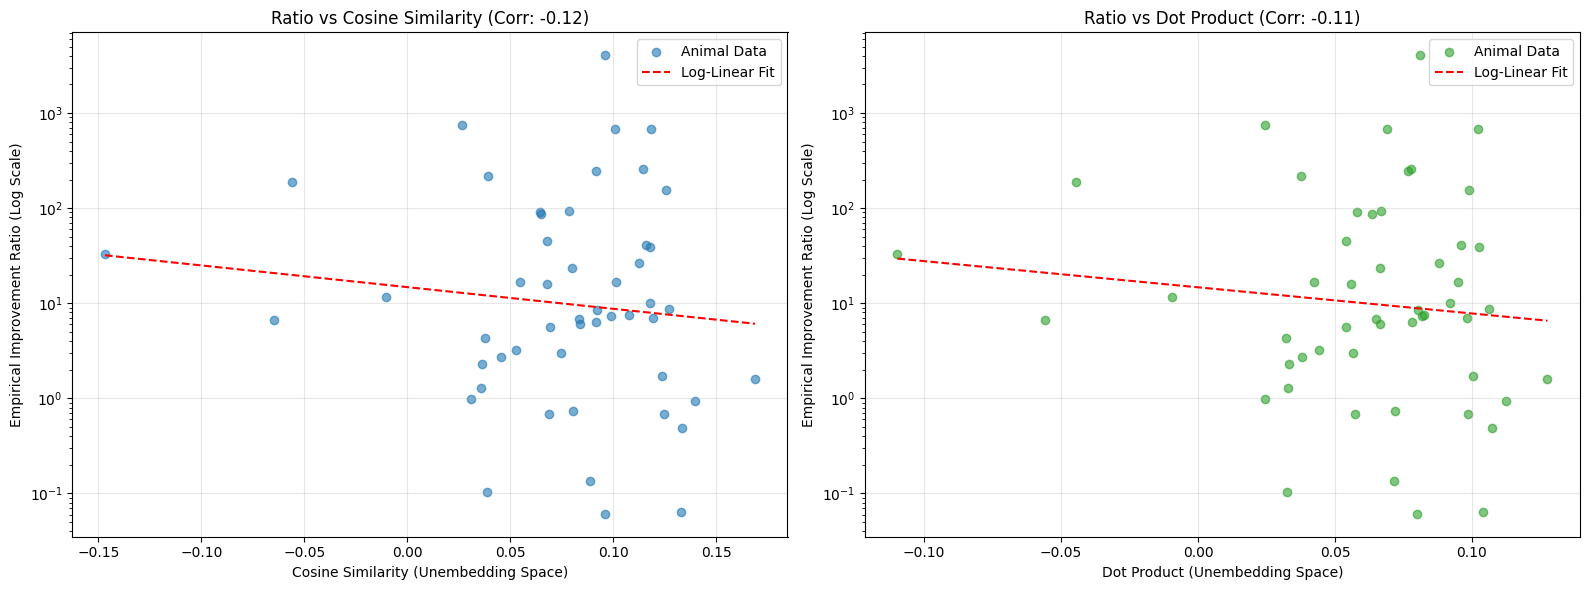

In [3]:
def get_trend_line(x, y):
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    return p

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Cosine Similarity
ax1.scatter(df['cosine_similarity'], df['empirical_ratio'], alpha=0.6, color='#1f77b4', label='Animal Data')
ax1.set_yscale('log')
ax1.set_xlabel('Cosine Similarity (Unembedding Space)')
ax1.set_ylabel('Empirical Improvement Ratio (Log Scale)')
ax1.set_title(f'Ratio vs Cosine Similarity (Corr: {cosine_pearson:.2f})')
ax1.grid(True, alpha=0.3)

p_cos = get_trend_line(df['cosine_similarity'], df['log_ratio'])
line_x = np.linspace(df['cosine_similarity'].min(), df['cosine_similarity'].max(), 100)
ax1.plot(line_x, 10**p_cos(line_x), color='red', linestyle='--', label='Log-Linear Fit')
ax1.legend()

# Plot 2: Dot Product
ax2.scatter(df['dot_product'], df['empirical_ratio'], alpha=0.6, color='#2ca02c', label='Animal Data')
ax2.set_yscale('log')
ax2.set_xlabel('Dot Product (Unembedding Space)')
ax2.set_ylabel('Empirical Improvement Ratio (Log Scale)')
ax2.set_title(f'Ratio vs Dot Product (Corr: {dot_pearson:.2f})')
ax2.grid(True, alpha=0.3)

p_dot = get_trend_line(df['dot_product'], df['log_ratio'])
line_x = np.linspace(df['dot_product'].min(), df['dot_product'].max(), 100)
ax2.plot(line_x, 10**p_dot(line_x), color='red', linestyle='--', label='Log-Linear Fit')
ax2.legend()

plt.tight_layout()
os.makedirs('../docs/reports', exist_ok=True)
plt.savefig('../docs/reports/unembedding_correlation_plots.png', dpi=150)
plt.show()

## 3. Notable Outliers
We identify cases where the geometry fails to predict the behavior.

In [4]:
print("Top Outliers (High Ratio, Low Cosine):")
outliers = df.sort_values(by='empirical_ratio', ascending=False)
display(outliers[['animal', 'empirical_ratio', 'cosine_similarity', 'dot_product']].head(10))

Top Outliers (High Ratio, Low Cosine):


,animal,empirical_ratio,cosine_similarity,dot_product
20,eagles,4048.762036,0.096255,0.081010
34,scorpions,756.241408,0.026468,0.024455
22,hawks,679.877289,0.118513,0.102265
3,tigers,677.538118,0.100994,0.068901
8,monkeys,260.129396,0.114266,0.077648
23,falcons,244.945853,0.091720,0.076724
44,capybaras,215.366121,0.039263,0.037460
7,zebras,188.349106,-0.056060,-0.044532
21,owls,155.771293,0.125754,0.099092
41,pangolins,92.591696,0.078648,0.066792


### Discussion: The Unembedding Hypothesis Failure

The visualizations reveal that while there is a general positive correlation between unembedding proximity and subliminal effectiveness, the relationship is highly noisy. 

Specifically, entities like **Scorpions** and **Eagles** show massive empirical spikes (756x and 4048x respectively) despite not having exceptionally high geometric scores in the `lm_head` matrix. 

This suggests that the purely geometric "Unembedding Hypothesis" (Cosine Similarity of final weights) is an incomplete model. Entanglement likely involves deeper internal representations within the transformer blocks.